# Detecting Fraudulent Credit Card Transactions

**Pillar 5 Capstone — Allen Mendiola**  ·  Finance domain

This notebook walks through the project and shows the main results.

The heavy work — training seven models, SHAP, the fairness audit — lives in the numbered
scripts in `src/`, because those take about 25 minutes to run. This notebook loads the
results those scripts saved, so it runs in seconds and always shows the same numbers as
the written report.

To regenerate everything from scratch, run `src/01_download_data.py` through
`src/08_bias_audit.py` in order first.

In [1]:
import os
import json

import pandas as pd
from IPython.display import Image, display

# Find the project folder. If we are running inside notebooks/, step up one level.
PROJECT = os.getcwd()
if os.path.basename(PROJECT) == "notebooks":
    PROJECT = os.path.dirname(PROJECT)

TABLES = os.path.join(PROJECT, "reports", "tables")
FIGURES = os.path.join(PROJECT, "reports", "figures")


def load_json(name):
    handle = open(os.path.join(TABLES, name))
    content = json.load(handle)
    handle.close()
    return content


def load_csv(name):
    return pd.read_csv(os.path.join(TABLES, name))


def show(figure_name):
    display(Image(filename=os.path.join(FIGURES, figure_name)))


print("Project folder:", PROJECT)
print("Result files found:", len(os.listdir(TABLES)))

Project folder: D:\Downloads\Allen_Mendiola\Pillar5
Result files found: 23


## Step 1 — The problem

Decide whether a card payment is fraudulent, at the moment it is attempted.

- **Task:** supervised binary classification, target `is_fraud`
- **Headline metric:** PR-AUC, *not* accuracy
- **Business measure:** fraud blocked, minus review cost, minus the cost of upsetting a genuine customer

In [2]:
overview = load_json("data_overview.json")

print("Transactions :", format(overview["n_rows"], ","))
print("Fraud        :", format(overview["n_fraud"], ","))
print("Fraud rate   : %.3f%%" % overview["fraud_rate_percent"])
print("Period       : %s to %s" % (overview["first_transaction"][:10],
                                   overview["last_transaction"][:10]))
print()
print("A model that always guessed 'genuine' would be %.2f%% accurate"
      % (100 - overview["fraud_rate_percent"]))
print("and would catch exactly zero fraud. That is why accuracy is not the metric.")

Transactions : 1,048,575
Fraud        : 6,006
Fraud rate   : 0.573%
Period       : 2019-01-01 to 2020-03-10

A model that always guessed 'genuine' would be 99.43% accurate
and would catch exactly zero fraud. That is why accuracy is not the metric.


## Step 2 — The data, and two problems found in it

Sparkov simulated transactions, downloaded from Hugging Face.

Chosen over the better-known ULB "creditcard" dataset for one reason: it keeps `gender`,
`dob`, `job` and `city_pop`. The ULB set is anonymised into unnamed components V1–V28,
which would make the Step 5 fairness audit impossible.

In [3]:
data_dictionary = load_csv("data_dictionary.csv")
data_dictionary[["variable", "description", "data_type", "unit_or_format"]]

,variable,description,data_type,unit_or_format
0,trans_date_trans_time,Date and time the transaction happened,object,text date (M/D/YY H:MM)
1,cc_num,Credit card number of the customer (identifier...,float64,number
2,merchant,Name of the shop where the card was used,object,text
3,category,"Type of purchase, for example grocery_pos or s...",object,text (14 categories)
4,amt,Amount of the transaction,float64,US dollars
5,first,Customer first name - PERSONAL DATA,object,text
6,last,Customer last name - PERSONAL DATA,object,text
7,gender,Gender of the cardholder - SENSITIVE ATTRIBUTE,object,M or F
8,street,Customer home street address - PERSONAL DATA,object,text
9,city,Customer home city,object,text


### Problem 1 — the file was truncated

It holds exactly **1,048,575** rows, which is precisely Excel's row limit. The original
Sparkov file has 1,296,675 rows, so roughly 248,000 transactions were lost before the
file was published.

### Problem 2 — birth dates read in the wrong century

Dates are stored as `M/D/YY`. Python reads a two-digit year below 69 as the 2000s, so
`1/19/62` became **2062**, not 1962 — giving customers born in the future and **negative
ages**.

This was caught only because a clustering profile reported an average customer age of
**minus 41 years**. Had it slipped through, the age fairness audit in Step 5 would have
been auditing nonsense while appearing to work perfectly.

In [4]:
print("Rows read with the wrong century: %s (%.1f%% of the file)"
      % (format(overview.get("dob_wrong_century_rows", 0), ","),
         overview.get("dob_wrong_century_percent", 0)))
print()
print("The fix, in src/03_clean_and_engineer.py:")
print("    born_in_the_future = df['dob'] > pd.Timestamp('2020-12-31')")
print("    df.loc[born_in_the_future, 'dob'] -= pd.DateOffset(years=100)")

Rows read with the wrong century: 358,189 (34.2% of the file)

The fix, in src/03_clean_and_engineer.py:
    born_in_the_future = df['dob'] > pd.Timestamp('2020-12-31')
    df.loc[born_in_the_future, 'dob'] -= pd.DateOffset(years=100)


## Step 3 — What the data shows

The single clearest pattern is the time of day.

Fraud rate at night (10pm-4am): 1.842%
Fraud rate during the day     : 0.118%
So fraud is 16 times more likely at night.

Average fraudulent payment: $526.22
Average genuine payment   : $67.64


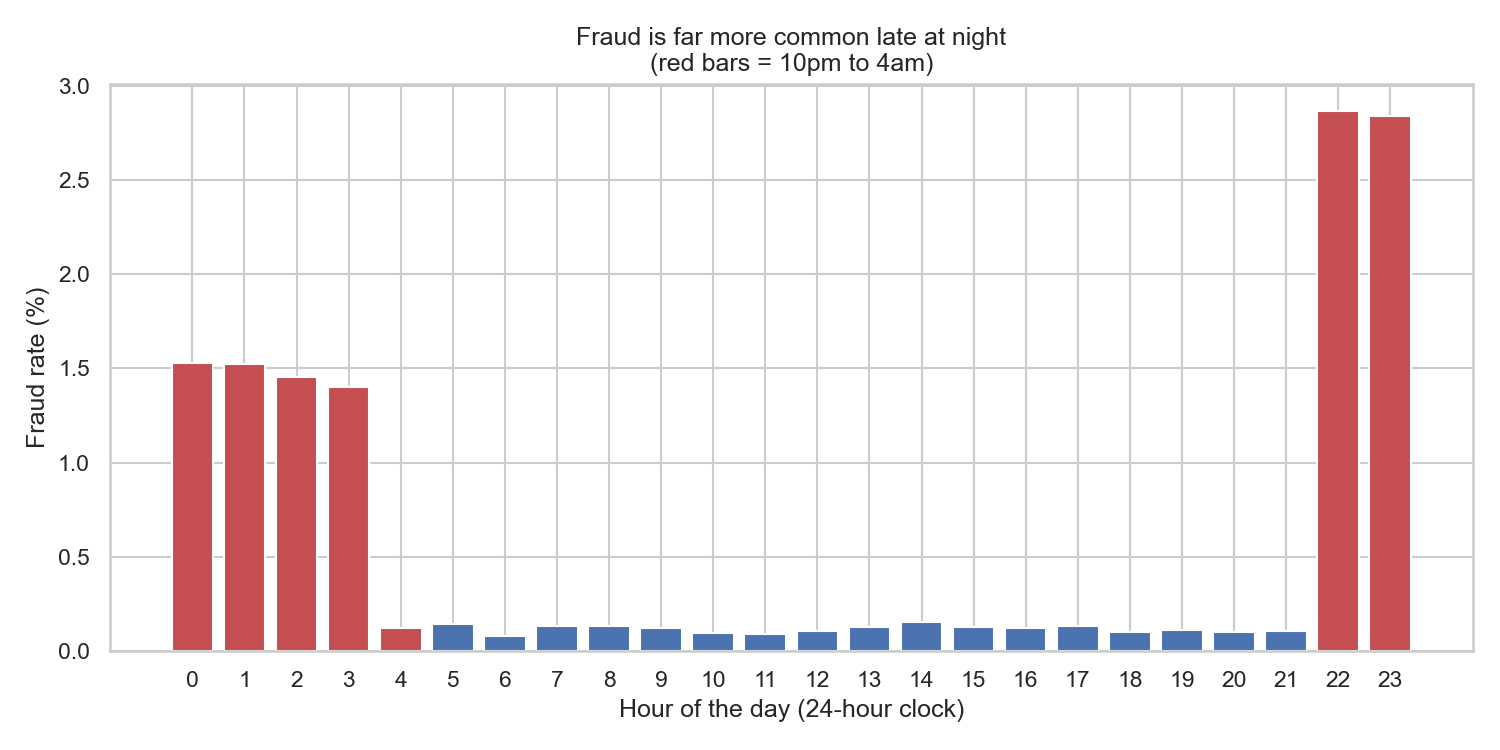

In [5]:
eda = load_json("eda_findings.json")

print("Fraud rate at night (10pm-4am): %.3f%%" % eda["night_fraud_rate_percent"])
print("Fraud rate during the day     : %.3f%%" % eda["day_fraud_rate_percent"])
print("So fraud is %.0f times more likely at night."
      % (eda["night_fraud_rate_percent"] / eda["day_fraud_rate_percent"]))
print()
print("Average fraudulent payment: $%.2f" % eda["average_fraud_amount"])
print("Average genuine payment   : $%.2f" % eda["average_genuine_amount"])

show("fig03_fraud_by_hour.png")

### Feature engineering

Thirteen features were built from the raw columns. Each exists for a stated reason.

In [6]:
load_csv("feature_engineering_notes.csv")

,feature,type,why_we_use_it
0,amt,Original,The payment amount. Fraudsters often test with...
1,amt_log,Engineered,Log of the amount. Squashes a very skewed rang...
2,amt_vs_card_avg,Engineered,Amount divided by this card's usual spend. Cat...
3,card_avg_amt,Engineered,"The card's normal spending level, learned from..."
4,merchant_freq,Engineered,How often the shop appears. Unknown shops carr...
5,age,Engineered,"Age at the time of payment, worked out from da..."
6,hour,Engineered,Hour of the day. Fraud peaks at night.
7,day_of_week,Engineered,"Day of the week, to capture weekly habits."
8,month,Engineered,"Month, to capture seasonal effects."
9,is_night,Engineered,"1 if between 10pm and 4am, when the real owner..."


Three things are worth pulling out:

- **The split is by date, not random.** Training uses earlier transactions, testing later
  ones. A random split would let the model learn from the future to predict the past.
- **Personal details are dropped.** Name, street, card number and postcode are removed
  before modelling — a privacy decision, not just tidying.
- **Gender and job are withheld** from the model, and kept only so Step 5 can audit it.

## Step 4 — Comparing seven models

In [7]:
comparison = load_csv("model_comparison.csv")
comparison[["model", "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]]

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Neural Network (MLP),0.9980,0.8811,0.7380,0.8032,0.9944,0.8613
1,Random Forest,0.9956,0.5612,0.8812,0.6857,0.9954,0.8605
2,XGBoost,0.9952,0.5402,0.8384,0.6571,0.9947,0.8307
3,Decision Tree,0.9713,0.1567,0.9712,0.2698,0.9835,0.6790
4,Support Vector Machine,0.9866,0.2623,0.8044,0.3956,0.9618,0.5087
5,Logistic Regression,0.9053,0.0497,0.9013,0.0941,0.9659,0.2377
6,Isolation Forest (unsupervised),0.9919,0.3195,0.4314,0.3671,0.9297,0.2212


Highest PR-AUC : Neural Network (MLP) (0.8613)
Deployed model : Random Forest (0.8605)

Those two are separated by 0.0008, which is noise rather than skill.
The tie was broken on explainability: SHAP is exact and fast on tree
models, but slow and approximate on a neural network. A bank that cannot
explain a declined payment cannot deploy the model, whatever its score.


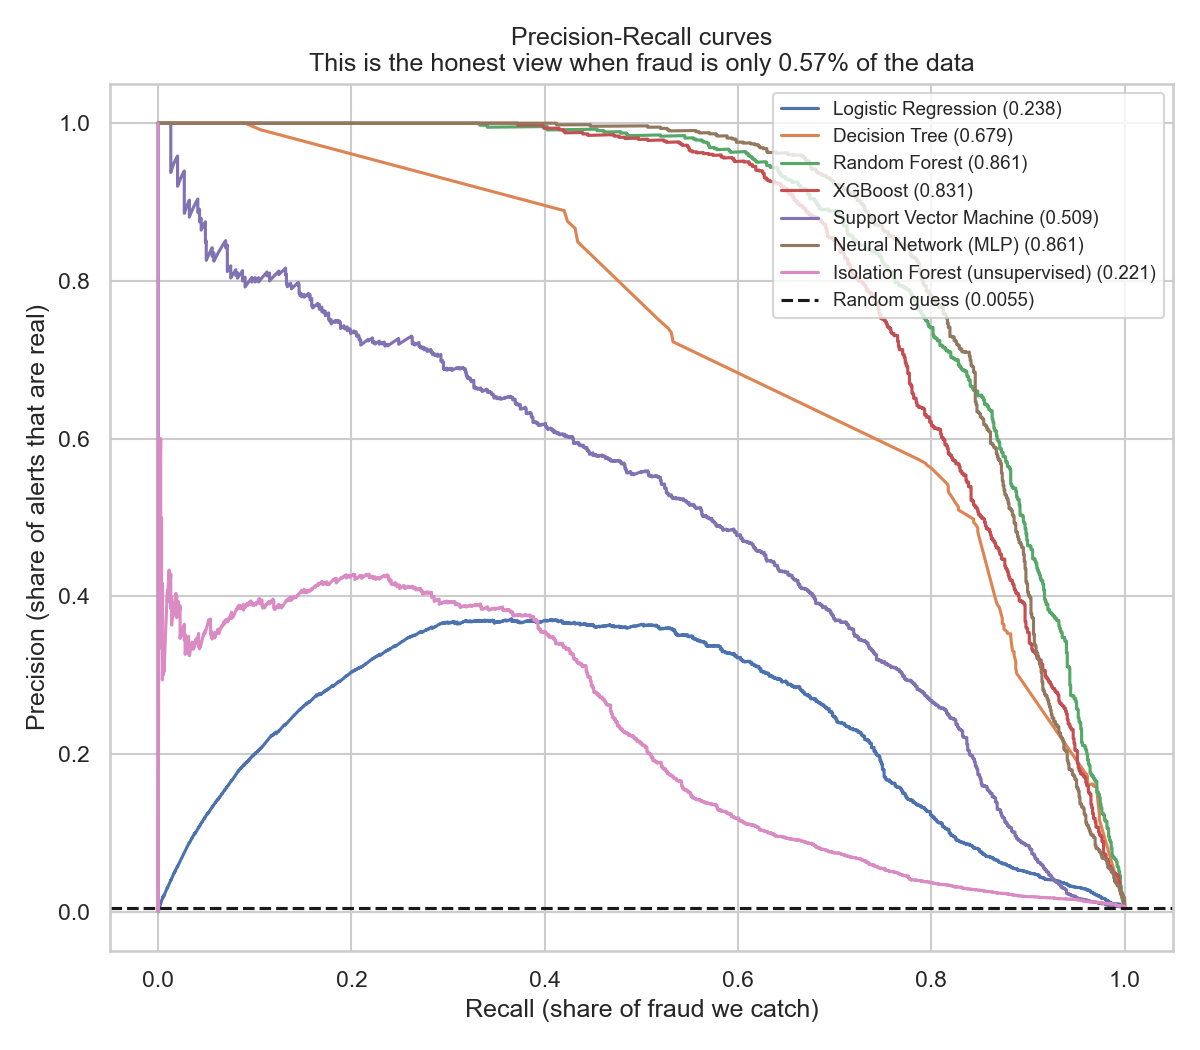

In [8]:
models = load_json("model_results.json")

print("Highest PR-AUC :", models["highest_pr_auc_model"], "(%.4f)" % models["highest_pr_auc"])
print("Deployed model :", models["best_model"], "(%.4f)" % models["best_pr_auc"])
print()

if models.get("chosen_for_explainability"):
    gap = models["highest_pr_auc"] - models["best_pr_auc"]
    print("Those two are separated by %.4f, which is noise rather than skill." % gap)
    print("The tie was broken on explainability: SHAP is exact and fast on tree")
    print("models, but slow and approximate on a neural network. A bank that cannot")
    print("explain a declined payment cannot deploy the model, whatever its score.")

show("fig12_pr_curves.png")

### A result that contradicts the textbook

Class weighting and SMOTE are the standard advice for imbalanced data. Both raised recall
sharply — and both *lowered* PR-AUC.

In [9]:
load_csv("imbalance_comparison.csv")

,approach,recall,precision,pr_auc
0,Do nothing,0.2568,0.8424,0.4016
1,Class weights,0.8952,0.0452,0.2427
2,SMOTE oversampling,0.8934,0.0437,0.2391


They do not make the model better at telling fraud from genuine payments — they move the
decision boundary, trading precision for recall. PR-AUC looks across every threshold, so
it sees through that trade.

The cleaner approach is to train on the real distribution and tune the threshold
deliberately, which makes the trade-off visible instead of hiding it inside training.

### Choosing the threshold with money

The usual 0.5 cut-off is a convention, not a business decision.

In [10]:
best = models["at_best_threshold"]

print("Chosen threshold          : %.2f" % best["threshold"])
print("Alerts raised             : %s" % format(best["alerts"], ","))
print("Fraud caught              : %s of %s (%.1f%%)"
      % (format(best["fraud_caught"], ","),
         format(best["fraud_caught"] + best["fraud_missed"], ","),
         best["recall"] * 100))
print("Alerts that are real fraud: %.0f%%" % (best["precision"] * 100))
print("Net benefit               : $%s" % format(best["net_benefit"], ",.0f"))

Chosen threshold          : 0.50
Alerts raised             : 1,798
Fraud caught              : 1,009 of 1,145 (88.1%)
Alerts that are real fraud: 56%
Net benefit               : $554,950


But how much should we trust that number? It depends entirely on an assumption we cannot
measure — what upsetting a genuine customer is actually worth.

In [11]:
load_csv("cost_sensitivity.csv")

,assumed_cost_per_false_alarm,best_threshold,alerts,fraud_caught,recall,net_benefit
0,0.0,0.25,3278,1077,0.9406,601815.76
1,15.0,0.40,2244,1034,0.9031,579411.21
2,45.0,0.50,1798,1009,0.8812,554949.62
3,100.0,0.65,1372,949,0.8288,522988.82
4,250.0,0.75,1132,891,0.7782,480469.89


The threshold moves a long way as that assumption changes. Nothing in the data settles
it — this is a business judgement wearing a mathematical costume, and it should be
presented as one.

### Finding fraud with no labels at all

In a real bank the fraud labels arrive weeks late. So can clustering find risky behaviour
without them?

K-Means best k      : 10 (silhouette 0.179)
Riskiest cluster    : 17.47% fraud, which is 26x the average

DBSCAN noise points : 1,190 (6.0%)
Fraud among noise   : 8.66%
Fraud among grouped : 0.170%

Transactions that fit no group are 51x more likely to be fraud.
'Does not look like anything else' is a fraud signal in its own right.


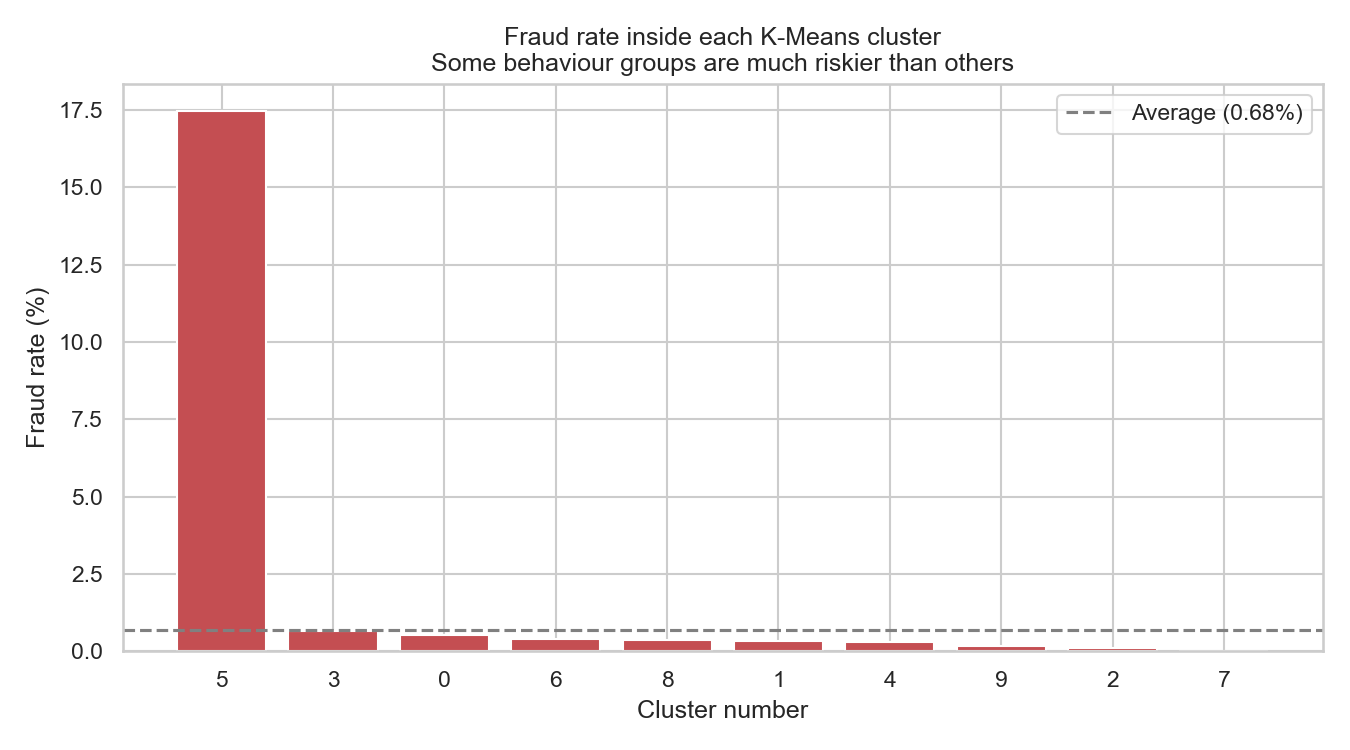

In [12]:
clusters = load_json("clustering_results.json")

print("K-Means best k      : %d (silhouette %.3f)"
      % (clusters["best_k"], clusters["best_silhouette"]))
print("Riskiest cluster    : %.2f%% fraud, which is %.0fx the average"
      % (clusters["riskiest_cluster_fraud_rate"], clusters.get("riskiest_cluster_lift", 0)))
print()
print("DBSCAN noise points : %s (%.1f%%)"
      % (format(clusters["dbscan_noise_count"], ","), clusters["dbscan_noise_percent"]))
print("Fraud among noise   : %.2f%%" % clusters["dbscan_noise_fraud_rate"])
print("Fraud among grouped : %.3f%%" % clusters["dbscan_cluster_fraud_rate"])
print()
print("Transactions that fit no group are %.0fx more likely to be fraud."
      % clusters.get("dbscan_noise_lift", 0))
print("'Does not look like anything else' is a fraud signal in its own right.")

show("fig17_cluster_fraud_rates.png")

In [13]:
load_csv("cluster_profiles.csv")

,cluster,transactions,share_percent,avg_amount,avg_hour,avg_distance_km,avg_age,fraud_rate_percent
0,5,372,1.9,638.27,14.6,77.8,44.4,17.473
1,3,3018,15.1,86.98,4.3,77.9,42.1,0.663
2,0,2099,10.5,95.96,9.5,80.7,41.8,0.524
3,6,1777,8.9,6.43,6.5,72.1,65.2,0.394
4,8,2206,11.0,74.02,12.6,82.1,74.2,0.363
5,1,2790,13.9,66.60,16.0,36.8,40.9,0.323
6,4,2570,12.8,7.42,17.5,81.2,39.3,0.311
7,9,3102,15.5,80.84,17.4,96.7,37.5,0.161
8,2,2035,10.2,14.38,17.2,80.1,36.3,0.098
9,7,31,0.2,1989.60,12.8,70.7,47.7,0.000


## Step 5 — Explaining the model

Top features by SHAP:
   - amt_log
   - amt
   - is_night
   - amt_vs_card_avg
   - hour

All behavioural: what was done, not who did it.


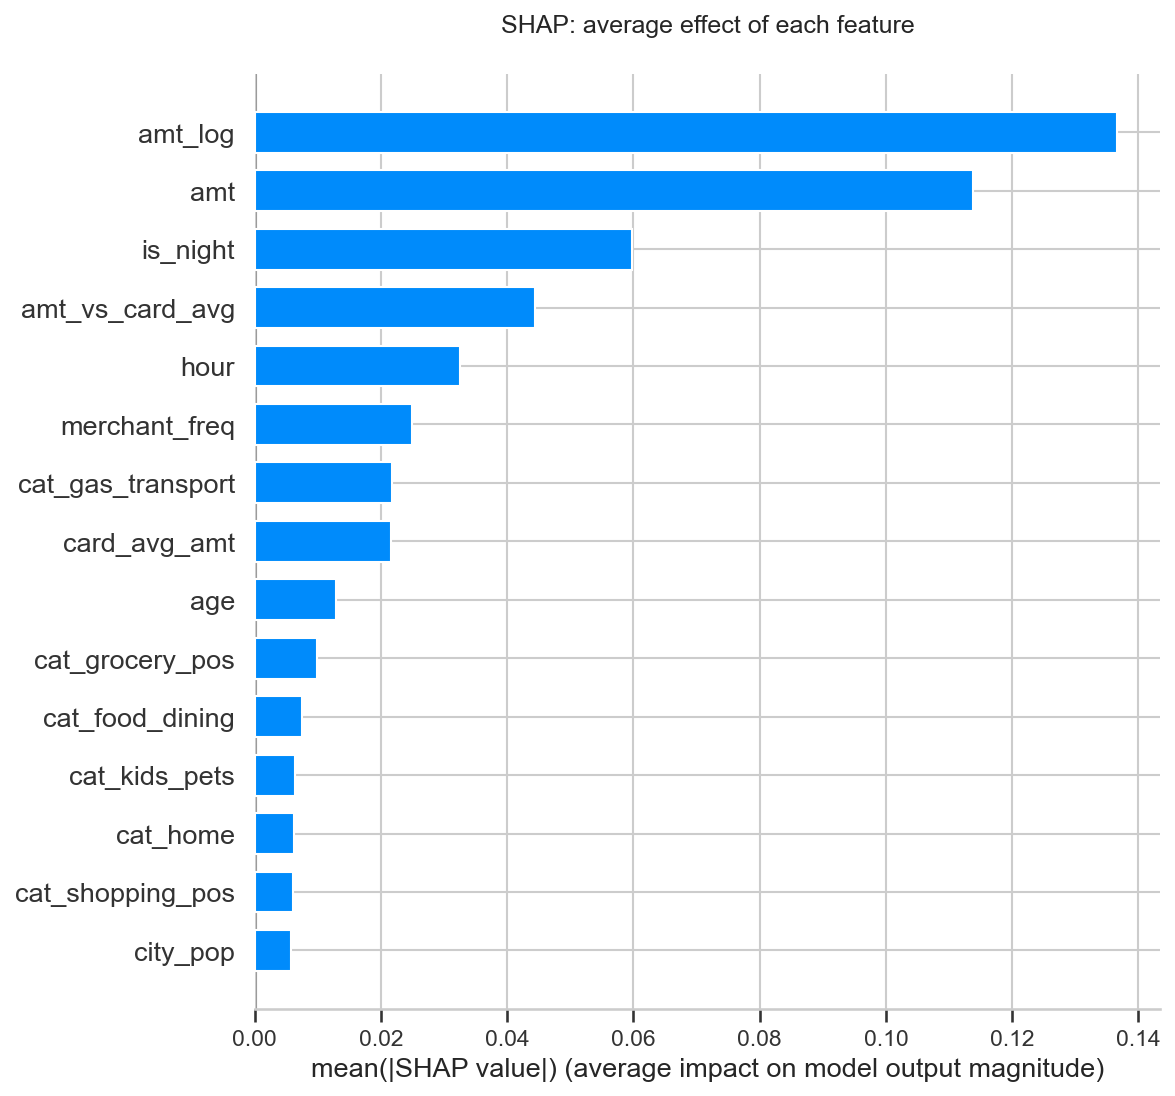

In [14]:
explain = load_json("explainability_results.json")

print("Top features by SHAP:")
for name in explain["top_5_shap_features"]:
    print("   -", name)
print()
print("All behavioural: what was done, not who did it.")

show("fig24_shap_bar.png")

## Step 5 — The fairness audit

The model was never given gender or job. Many people assume that alone makes a model
fair. This is the test of that assumption.

In [15]:
print("=== BY GENDER (never given to the model) ===")
display(load_csv("bias_by_gender.csv"))

print("=== BY AGE (age IS given to the model) ===")
display(load_csv("bias_by_age.csv"))

print("=== BY CITY SIZE (a stand-in for wealth) ===")
display(load_csv("bias_by_city_size.csv"))

=== BY GENDER (never given to the model) ===


,group,people,actual_fraud,base_rate_percent,selection_rate_percent,tpr_percent,fpr_percent,precision_percent,false_alarms,missed_fraud
0,F,114889,614,0.534,0.926,85.67,0.471,49.44,538,88
1,M,94826,531,0.560,0.774,90.96,0.266,65.80,251,48


=== BY AGE (age IS given to the model) ===


,group,people,actual_fraud,base_rate_percent,selection_rate_percent,tpr_percent,fpr_percent,precision_percent,false_alarms,missed_fraud
0,30-44,70152,341,0.486,0.976,85.34,0.564,42.48,394,50
1,45-59,56117,353,0.629,0.887,89.24,0.328,63.25,183,38
2,60 and over,44734,294,0.657,0.709,89.12,0.124,82.65,55,32
3,Under 30,38712,157,0.406,0.770,89.81,0.407,47.32,157,16


=== BY CITY SIZE (a stand-in for wealth) ===


,group,people,actual_fraud,base_rate_percent,selection_rate_percent,tpr_percent,fpr_percent,precision_percent,false_alarms,missed_fraud
0,City,28742,188,0.654,1.110,90.43,0.522,53.29,149,18
1,Large city,10638,54,0.508,0.761,90.74,0.302,60.49,32,5
2,Rural,105655,551,0.522,0.671,85.66,0.225,66.57,237,79
3,Small town,64680,352,0.544,1.065,90.34,0.577,46.15,371,34


In [16]:
fairness = load_json("fairness_results.json")

for attribute in ["gender", "age_band", "city_size"]:
    gaps = fairness[attribute]
    verdict = "PASS" if gaps["passes_80_percent_rule"] else "FAIL"
    print("%-10s disparate impact %.3f   [%s the 80%% rule]"
          % (attribute, gaps["disparate_impact_ratio"], verdict))
    print("%-10s worst served: %s, only %.1f%% of its fraud caught"
          % ("", gaps["least_protected_group"], gaps["least_protected_tpr"]))
    print()

gender     disparate impact 0.836   [PASS the 80% rule]
           worst served: F, only 85.7% of its fraud caught

age_band   disparate impact 0.726   [FAIL the 80% rule]
           worst served: 30-44, only 85.3% of its fraud caught

city_size  disparate impact 0.605   [FAIL the 80% rule]
           worst served: Rural, only 85.7% of its fraud caught



**The finding:** gender never entered the model, yet women have noticeably less of their
fraud caught than men. Two of the three attributes fail the 80% legal test outright.

Protected characteristics leave fingerprints on other columns — spending category, city
size, timing and typical amounts all correlate with demographics, so the model
reconstructs part of what was withheld.

> Removing a sensitive column removes your ability to **see** its effect, not the effect
> itself. Fairness through unawareness stops direct discrimination and does nothing about
> indirect discrimination through proxies.

### Can it be fixed, and what does the fix cost?

Method: per-group thresholds on age band

Protection gap : 4.47  ->  0.07 percentage points
Fraud caught   : 1,009  ->  1,028
False alarms   : 789  ->  1,102

The gap nearly closes and 19 more frauds are caught -
but it costs 313 extra false alarms for the team to work through.


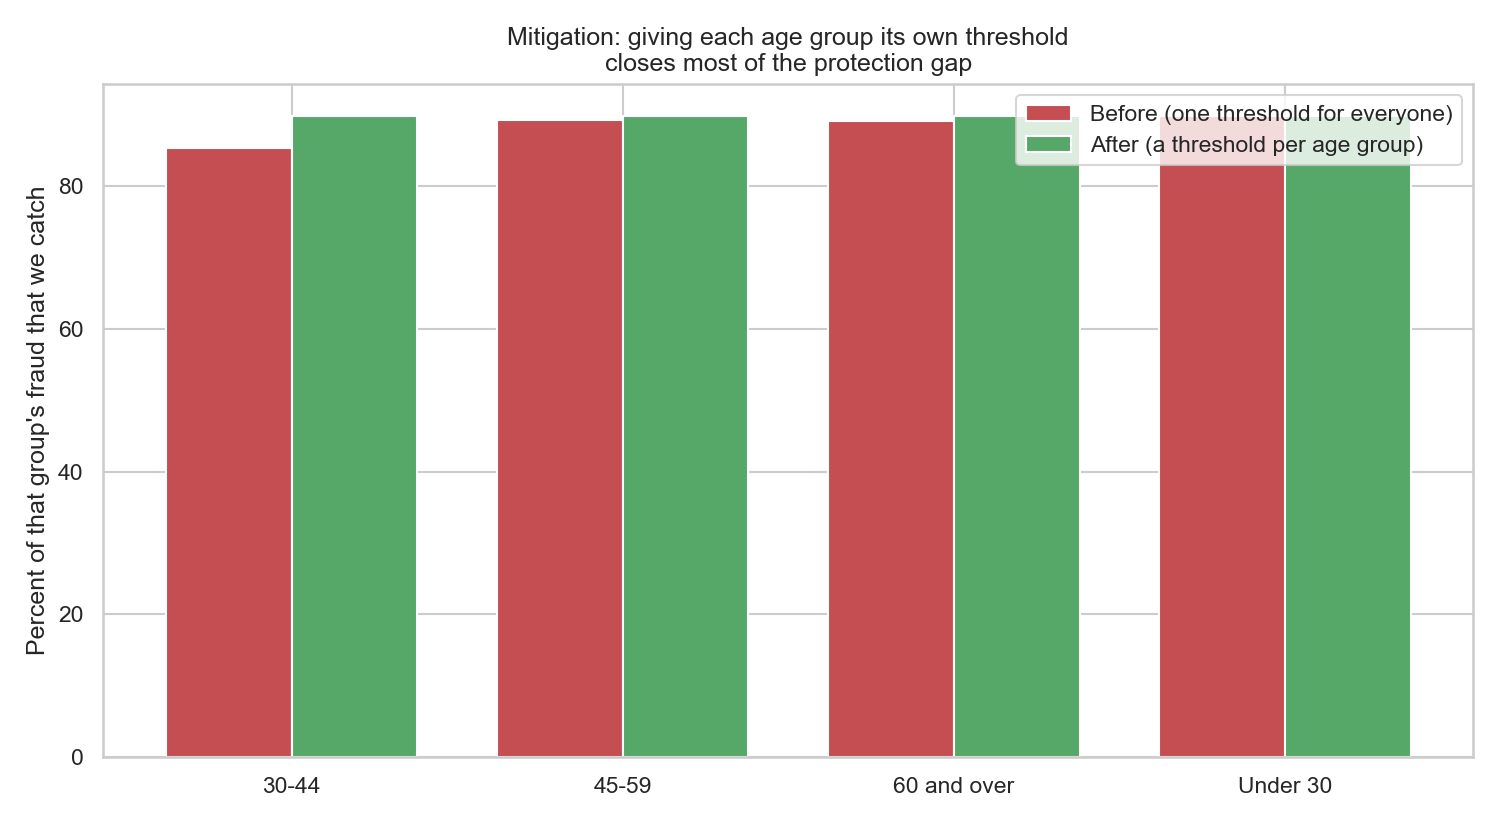

In [17]:
mitigation = fairness["mitigation"]

print("Method:", mitigation["method"])
print()
print("Protection gap : %.2f  ->  %.2f percentage points"
      % (mitigation["gap_before"], mitigation["gap_after"]))
print("Fraud caught   : %s  ->  %s"
      % (format(mitigation["fraud_caught_before"], ","),
         format(mitigation["fraud_caught_after"], ",")))
print("False alarms   : %s  ->  %s"
      % (format(mitigation["false_alarms_before"], ","),
         format(mitigation["false_alarms_after"], ",")))
print()
print("The gap nearly closes and %d more frauds are caught -"
      % (mitigation["fraud_caught_after"] - mitigation["fraud_caught_before"]))
print("but it costs %d extra false alarms for the team to work through."
      % (mitigation["false_alarms_after"] - mitigation["false_alarms_before"]))

show("fig32_mitigation_effect.png")

## Conclusion

There is no setting that is simultaneously the most accurate, the most profitable and the
most equal. Someone has to decide what the organisation will pay for equal treatment —
and that should be an accountable human decision, not something quietly settled by
whoever picked the default threshold.

**Main limitation:** this data is simulated. The methodology transfers; the specific
numbers will not. Nothing should go live without a shadow run against real transactions.

Full write-up: `Allen_Mendiola_Credit_Card_Fraud_Detection.pdf`